# Tesla Deliveries ML Pipeline (2015–2025)

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn – preprocessing & models
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Time-series
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

print("All libraries imported successfully")


All libraries imported successfully


In [2]:
# Load the dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Shape:", df.shape)
df.head()


Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# Check data types and basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
# Summary statistics
df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.sample(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
1131,2024,2,Asia,Model X,13035,14376,51251.49,60,336,656.96,Interpolated (Month),3833
1991,2024,11,Middle East,Model 3,11275,11994,92285.05,100,552,933.57,Official (Quarter),13106
1960,2025,2,Europe,Model 3,9545,10518,112809.79,75,417,597.04,Interpolated (Month),6004
1880,2015,6,Europe,Model 3,8922,9609,104855.71,75,427,571.45,Official (Quarter),10465
249,2025,12,North America,Cybertruck,9701,10572,66908.00,82,471,685.38,Official (Quarter),3889
1781,2023,5,Middle East,Model Y,12274,13261,102631.34,75,417,767.74,Estimated (Region),7179
847,2016,4,Asia,Model 3,8734,9416,93651.00,60,332,434.95,Official (Quarter),12063
608,2016,6,North America,Model X,5812,5963,56887.70,100,583,508.26,Official (Quarter),12172
54,2015,4,Asia,Model Y,7633,8492,102818.00,82,455,520.95,Estimated (Region),13830
801,2020,10,North America,Model S,10348,10789,53294.28,100,583,904.93,Interpolated (Month),13353


In [8]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


## Exploratory Data Analysis (EDA)

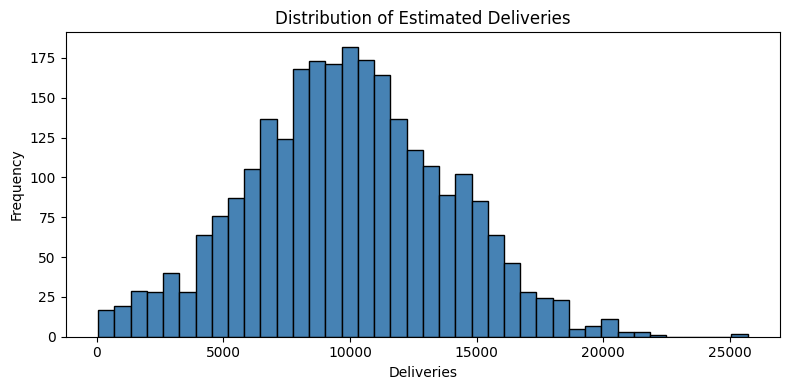

In [11]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
plt.hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Deliveries')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


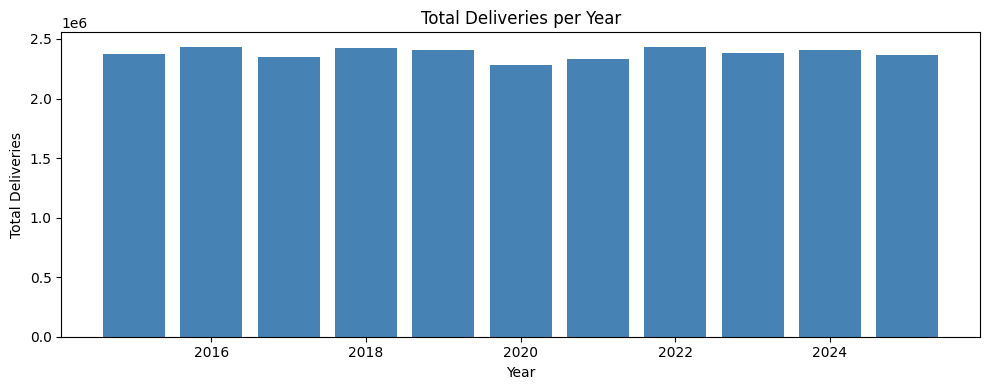

In [12]:
# Total deliveries by year
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(10, 4))
plt.bar(yearly['Year'], yearly['Estimated_Deliveries'], color='steelblue')
plt.title('Total Deliveries per Year')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()


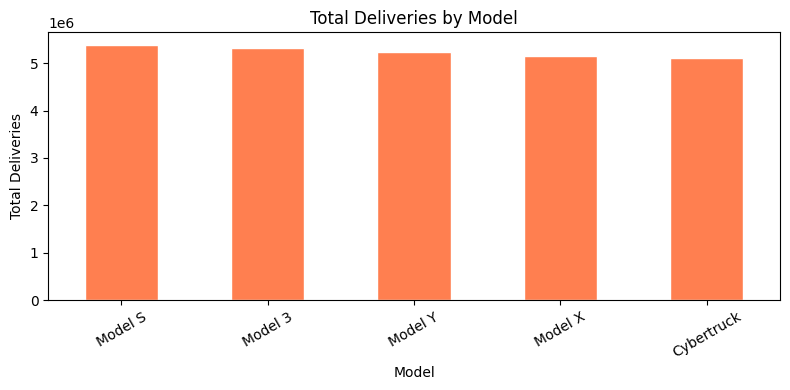

In [13]:
# Deliveries by model
model_total = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
model_total.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Total Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


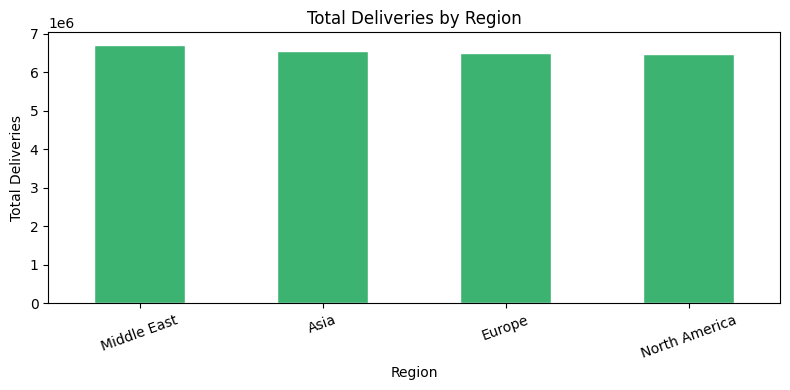

In [14]:
# Deliveries by region
region_total = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
region_total.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Total Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


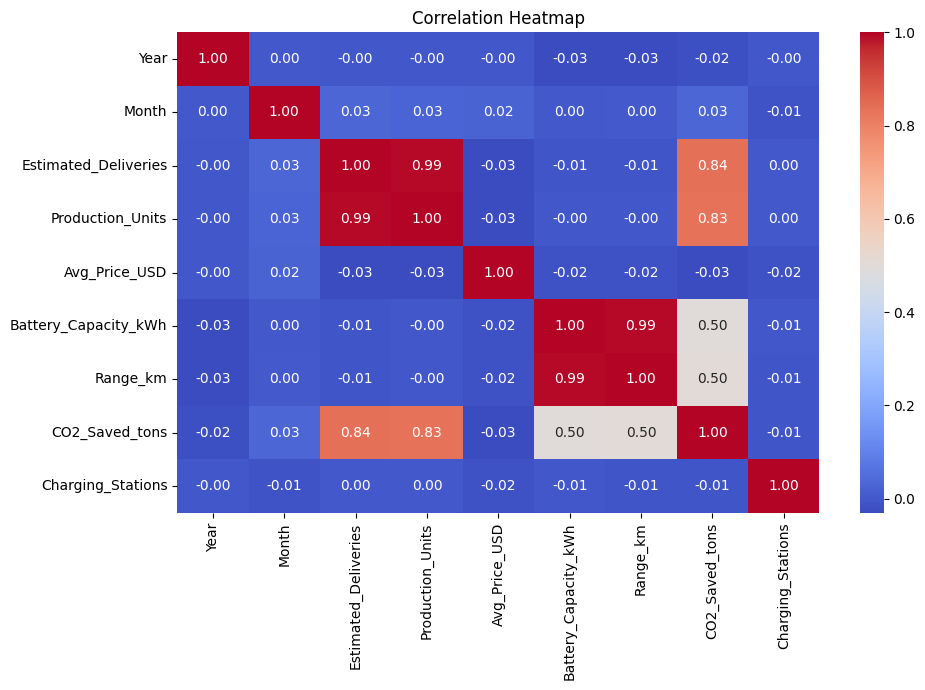

In [15]:
# Correlation heatmap of numeric features
num_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


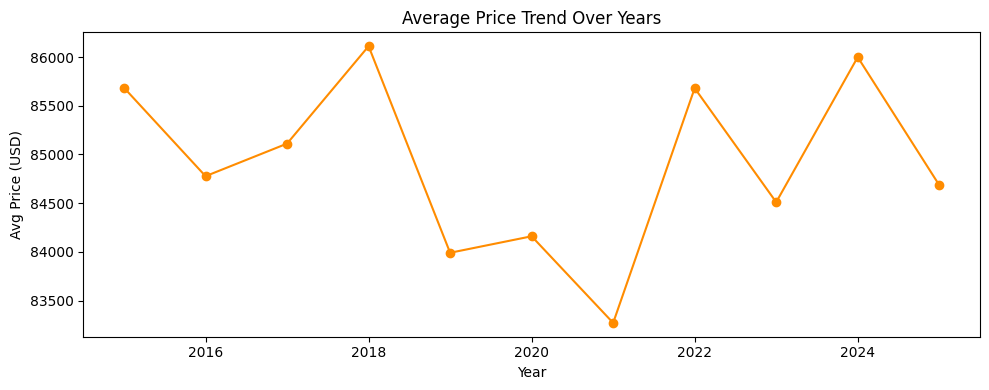

In [16]:
# Average price trend over years
avg_price = df.groupby('Year')['Avg_Price_USD'].mean()

plt.figure(figsize=(10, 4))
plt.plot(avg_price.index, avg_price.values, marker='o', color='darkorange')
plt.title('Average Price Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Avg Price (USD)')
plt.tight_layout()
plt.show()


## Preprocessing & Feature Engineering

In [17]:
# Encode categorical columns
le = LabelEncoder()
df['Region_encoded'] = le.fit_transform(df['Region'])
df['Model_encoded'] = le.fit_transform(df['Model'])

# Create new features from date info
df['Quarter'] = ((df['Month'] - 1) // 3) + 1
df['Season'] = df['Month'].map({
    1:'Winter', 2:'Winter', 3:'Spring',
    4:'Spring', 5:'Spring', 6:'Summer',
    7:'Summer', 8:'Summer', 9:'Autumn',
    10:'Autumn', 11:'Autumn', 12:'Winter'
})
df['Season_encoded'] = le.fit_transform(df['Season'])

# Interaction feature: price per km range
df['Price_per_km'] = df['Avg_Price_USD'] / df['Range_km']

# Log transform of target to reduce skewness
df['Log_Deliveries'] = np.log1p(df['Estimated_Deliveries'])

print("Feature engineering done. New columns:", 
      ['Region_encoded','Model_encoded','Quarter','Season_encoded','Price_per_km','Log_Deliveries'])
df.head(3)


Feature engineering done. New columns: ['Region_encoded', 'Model_encoded', 'Quarter', 'Season_encoded', 'Price_per_km', 'Log_Deliveries']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_encoded,Model_encoded,Quarter,Season,Season_encoded,Price_per_km,Log_Deliveries
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,1,2,2,Spring,1,131.923679,9.778321
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0,3,1,Winter,3,142.022032,8.242230
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,3,3,1,Winter,3,245.598583,9.037415


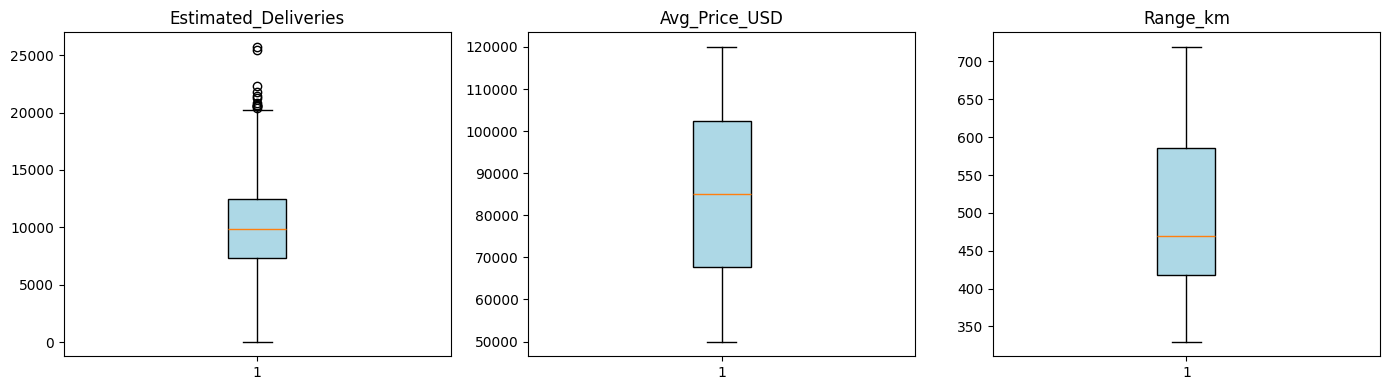

In [18]:
# Boxplot to spot outliers in key columns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Estimated_Deliveries', 'Avg_Price_USD', 'Range_km']):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [19]:
# Remove outliers using IQR method on target column
Q1 = df['Estimated_Deliveries'].quantile(0.25)
Q3 = df['Estimated_Deliveries'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['Estimated_Deliveries'] >= Q1 - 1.5*IQR) &
              (df['Estimated_Deliveries'] <= Q3 + 1.5*IQR)].copy()

print("Rows before:", len(df))
print("Rows after outlier removal:", len(df_clean))


Rows before: 2640
Rows after outlier removal: 2628


## Regression Modeling

In [20]:
# Define features and target
features = ['Year', 'Month', 'Quarter', 'Region_encoded', 'Model_encoded',
            'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations', 'Price_per_km', 'Season_encoded']

X = df_clean[features]
y = df_clean['Estimated_Deliveries']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train size:", X_train.shape, " | Test size:", X_test.shape)


Train size: (2102, 12)  | Test size: (526, 12)


In [21]:
# Train multiple regression models
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    results[name] = {
        'R2'  : round(r2_score(y_test, preds), 4),
        'MAE' : round(mean_absolute_error(y_test, preds), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 2)
    }

results_df = pd.DataFrame(results).T
print(results_df)


                       R2     MAE    RMSE
Linear Regression  0.9417  633.11  895.86
Ridge              0.9418  632.70  895.54
Lasso              0.9417  632.52  895.91
Random Forest      0.9980  108.63  166.23
Gradient Boosting  0.9974  144.06  189.31


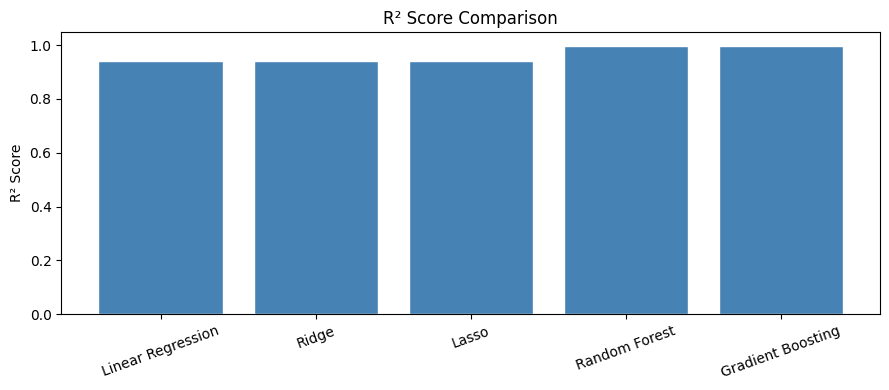

In [22]:
# Bar chart comparing R2 scores
plt.figure(figsize=(9, 4))
plt.bar(results_df.index, results_df['R2'], color='steelblue', edgecolor='white')
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Hyperparameter Tuning – Random Forest

In [24]:
# Grid search on Random Forest
param_grid = {
    'n_estimators'  : [50, 100, 200],
    'max_depth'     : [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
gs = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_train_sc, y_train)

print("Best params:", gs.best_params_)
print("Best CV R2 :", round(gs.best_score_, 4))


Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2 : 0.9958


In [25]:
# Evaluate best model on test set
best_rf = gs.best_estimator_
best_preds = best_rf.predict(X_test_sc)

print("Test R2 :", round(r2_score(y_test, best_preds), 4))
print("Test MAE:", round(mean_absolute_error(y_test, best_preds), 2))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, best_preds)), 2))


Test R2 : 0.998
Test MAE: 106.36
Test RMSE: 164.1


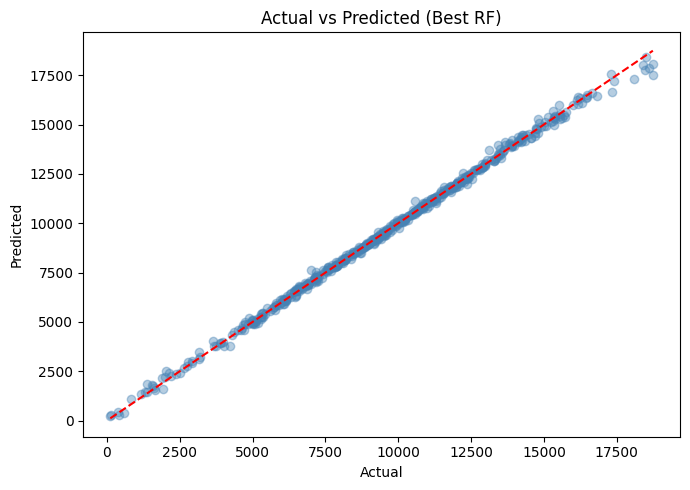

In [26]:
# Actual vs Predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Best RF)')
plt.tight_layout()
plt.show()


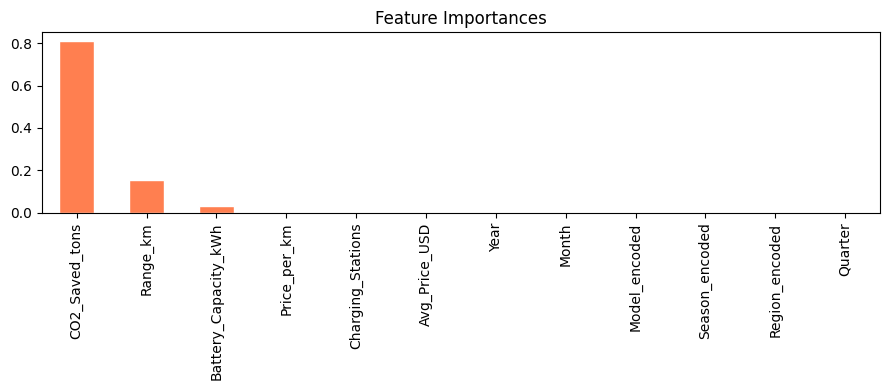

In [27]:
# Feature importance
feat_imp = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
feat_imp.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()


In [28]:
# 5-fold cross-validation on best model
cv_scores = cross_val_score(best_rf, X_train_sc, y_train, cv=5, scoring='r2')
print("CV R2 scores:", np.round(cv_scores, 4))
print("Mean:", round(cv_scores.mean(), 4), "| Std:", round(cv_scores.std(), 4))


CV R2 scores: [0.9957 0.9975 0.9977 0.9957 0.9961]
Mean: 0.9966 | Std: 0.0009


## Time Series Forecasting

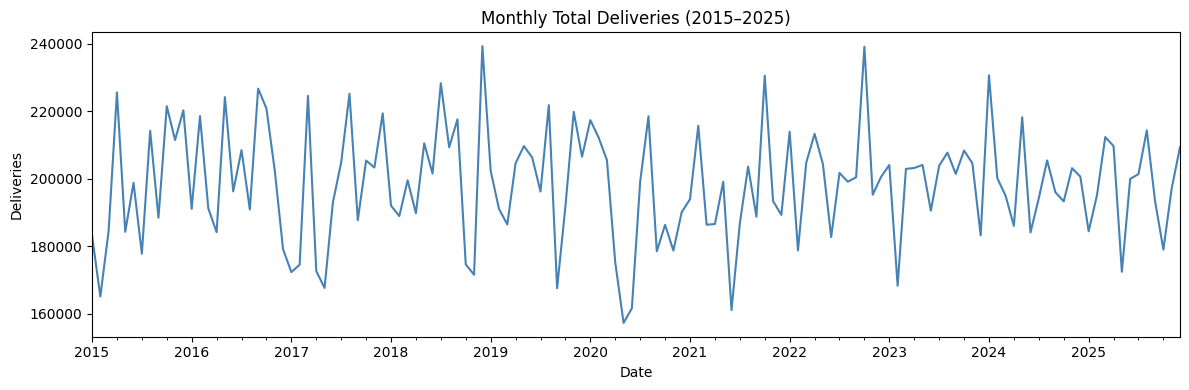

In [29]:
# Aggregate total monthly deliveries across all regions/models
ts = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts['Date'] = pd.to_datetime(ts[['Year','Month']].assign(day=1))
ts = ts.set_index('Date').sort_index()
ts_series = ts['Estimated_Deliveries']

plt.figure(figsize=(12, 4))
ts_series.plot(color='steelblue')
plt.title('Monthly Total Deliveries (2015–2025)')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()


/home/peeyush/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


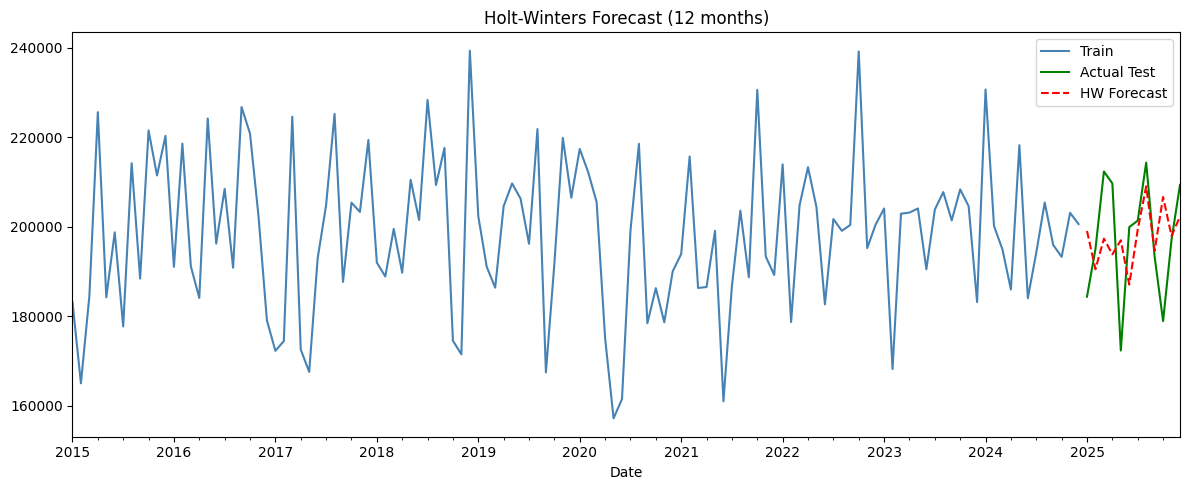

In [30]:
# Train/test split for time series (last 12 months = test)
train_ts = ts_series[:-12]
test_ts  = ts_series[-12:]

# Fit Holt-Winters Exponential Smoothing
hw_model = ExponentialSmoothing(train_ts, trend='add', seasonal='add', seasonal_periods=12)
hw_fit   = hw_model.fit()
hw_pred  = hw_fit.forecast(12)

# Plot
plt.figure(figsize=(12, 5))
train_ts.plot(label='Train', color='steelblue')
test_ts.plot(label='Actual Test', color='green')
hw_pred.plot(label='HW Forecast', color='red', linestyle='--')
plt.title('Holt-Winters Forecast (12 months)')
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
# Evaluate HW forecast
hw_rmse = np.sqrt(mean_squared_error(test_ts, hw_pred))
hw_mae  = mean_absolute_error(test_ts, hw_pred)
print(f"HW RMSE : {hw_rmse:.2f}")
print(f"HW MAE  : {hw_mae:.2f}")


HW RMSE : 13948.94
HW MAE  : 10977.96


/home/peeyush/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/peeyush/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/peeyush/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


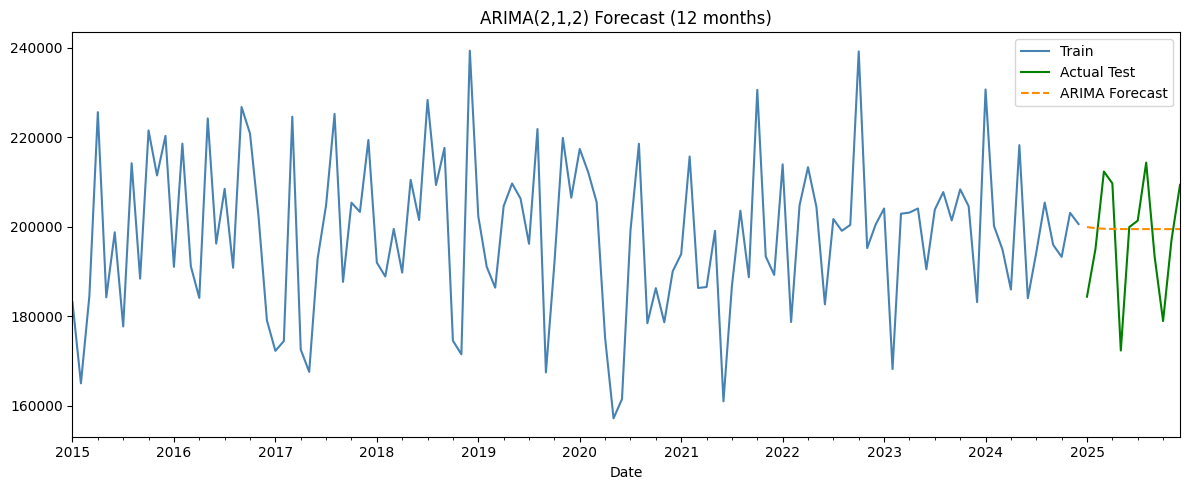

In [32]:
# ARIMA model
arima_model = ARIMA(train_ts, order=(2, 1, 2))
arima_fit   = arima_model.fit()
arima_pred  = arima_fit.forecast(12)

# Plot
plt.figure(figsize=(12, 5))
train_ts.plot(label='Train', color='steelblue')
test_ts.plot(label='Actual Test', color='green')
arima_pred.plot(label='ARIMA Forecast', color='darkorange', linestyle='--')
plt.title('ARIMA(2,1,2) Forecast (12 months)')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
# Evaluate ARIMA
arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_pred))
arima_mae  = mean_absolute_error(test_ts, arima_pred)
print(f"ARIMA RMSE : {arima_rmse:.2f}")
print(f"ARIMA MAE  : {arima_mae:.2f}")

print()
print("Summary – Time Series Models")
print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10}")
print(f"{'Holt-Winters':<20} {hw_rmse:>10.2f} {hw_mae:>10.2f}")
print(f"{'ARIMA(2,1,2)':<20} {arima_rmse:>10.2f} {arima_mae:>10.2f}")


ARIMA RMSE : 13085.38
ARIMA MAE  : 10535.63

Summary – Time Series Models
Model                      RMSE        MAE
Holt-Winters           13948.94   10977.96
ARIMA(2,1,2)           13085.38   10535.63


/home/peeyush/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


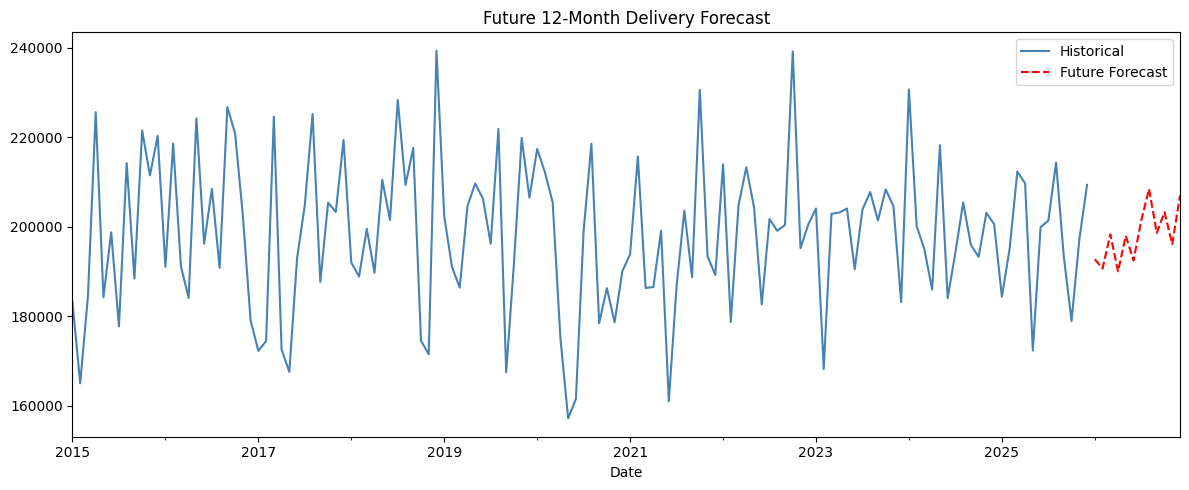

Forecast values:
2026-01-01    192762.0
2026-02-01    190694.0
2026-03-01    198330.0
2026-04-01    190057.0
2026-05-01    197998.0
2026-06-01    192482.0
2026-07-01    201470.0
2026-08-01    208473.0
2026-09-01    198641.0
2026-10-01    203287.0
2026-11-01    196142.0
2026-12-01    207024.0
Freq: MS, dtype: float64


In [34]:
# Future forecast – next 12 months using Holt-Winters (full data)
hw_full = ExponentialSmoothing(ts_series, trend='add', seasonal='add', seasonal_periods=12).fit()
future  = hw_full.forecast(12)

plt.figure(figsize=(12, 5))
ts_series.plot(label='Historical', color='steelblue')
future.plot(label='Future Forecast', color='red', linestyle='--')
plt.title('Future 12-Month Delivery Forecast')
plt.legend()
plt.tight_layout()
plt.show()

print("Forecast values:")
print(future.round(0))
